<a href="https://colab.research.google.com/github/KhoirotunNisa25/PCVK_Ganjil_2025/blob/main/Case_Method_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Studi Kasus

Seorang peneliti sedang mengembangkan sistem face recognition berbasis machine
learning dari dataset wajah manusia yang diambil di berbagai kondisi pencahayaan
(terang, gelap, dan berbayang).
Namun, hasil akurasi model masih rendah karena:
- beberapa wajah tampak terlalu gelap,
- sebagian memiliki kontras rendah,
- dan beberapa hasil masking kehilangan detail tepi wajah (mata, bibir).
Anda diminta melakukan pra-pemrosesan citra wajah manusia agar siap digunakan
dalam pelatihan model.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## A. Observasi dan Eksperimen

1. Tampilkan histogram tiap citra dan analisis distribusi intensitasnya.

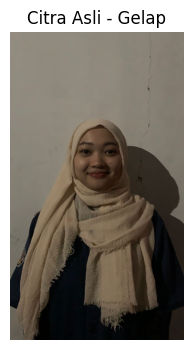

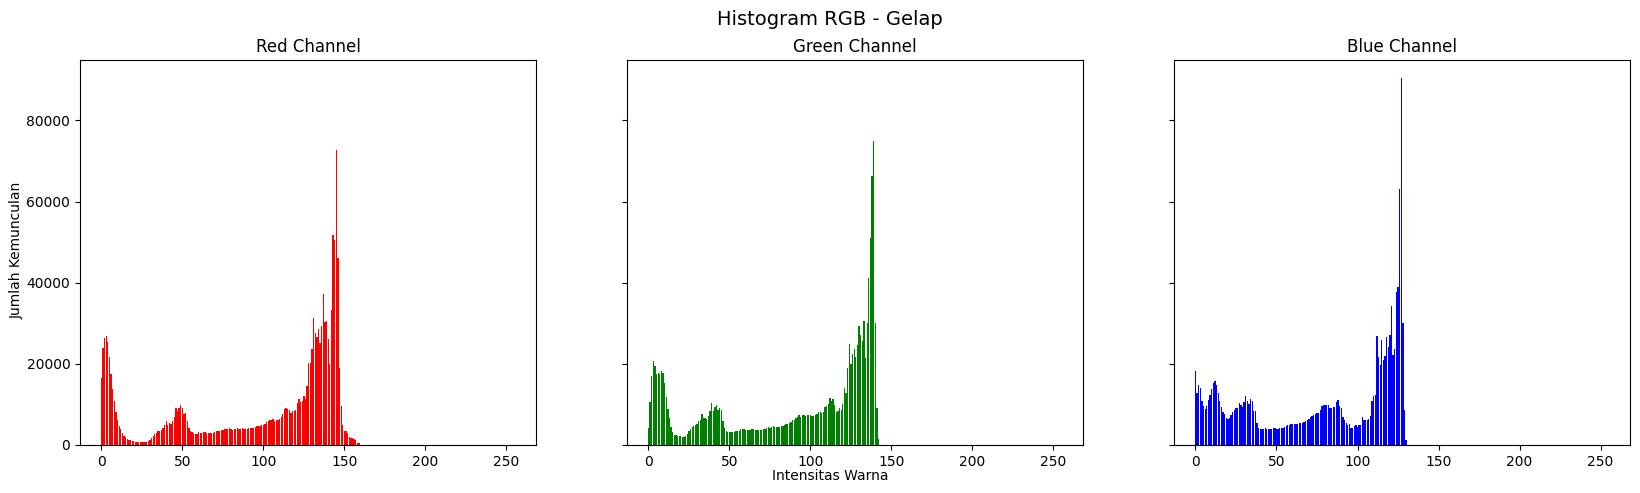

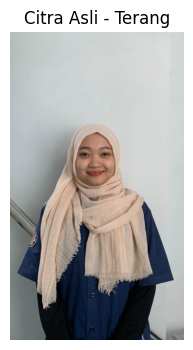

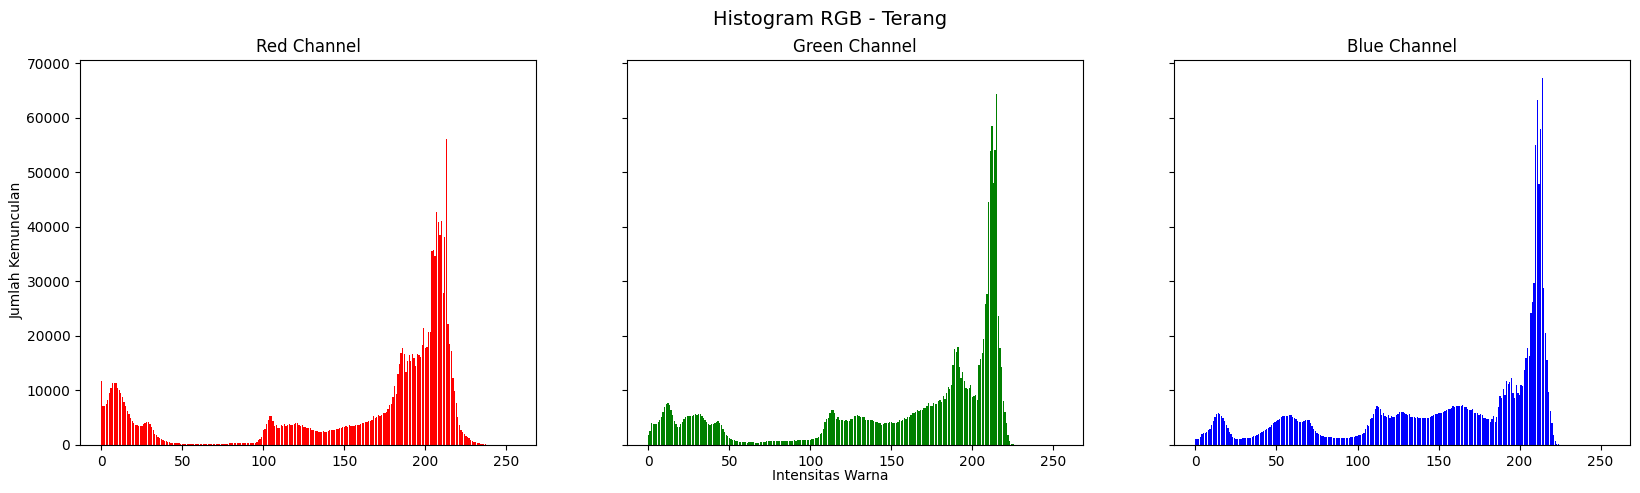

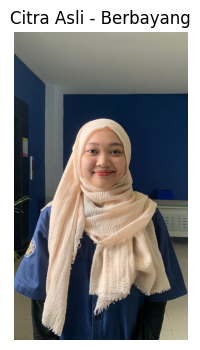

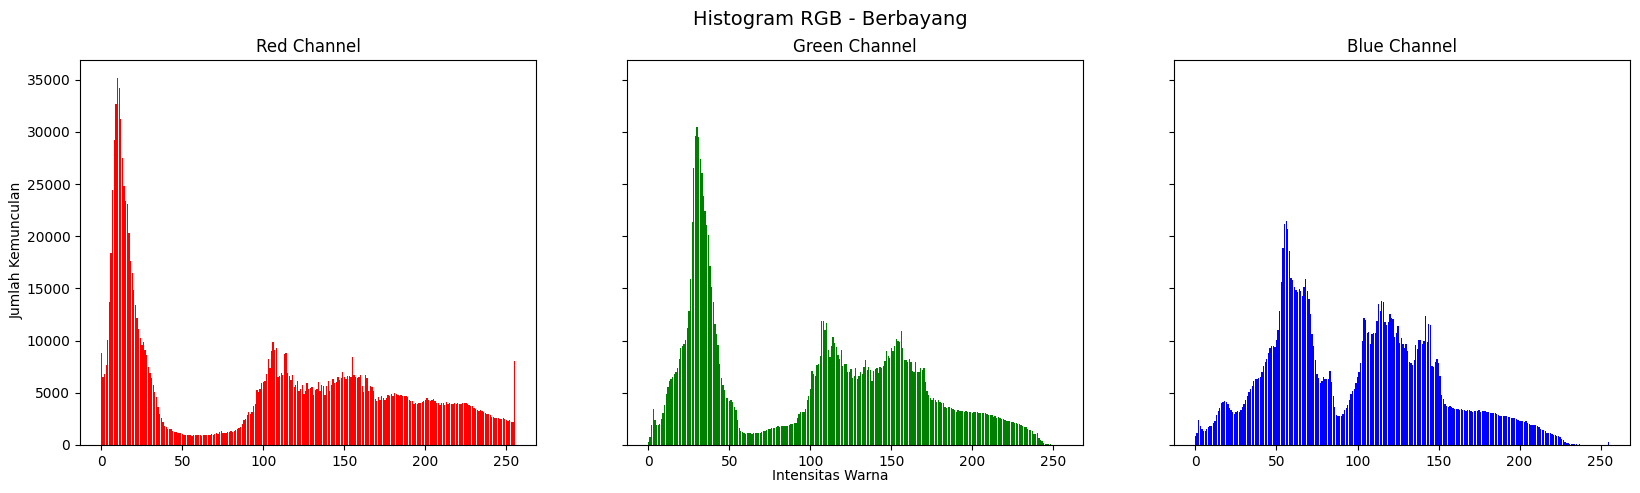

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load 3 gambar (ubah ke RGB)
img_gelap     = cv.cvtColor(cv.imread('/content/drive/MyDrive/PCVK/Images/foto1.jpg'), cv.COLOR_BGR2RGB)
img_terang    = cv.cvtColor(cv.imread('/content/drive/MyDrive/PCVK/Images/foto2.jpg'), cv.COLOR_BGR2RGB)
img_berbayang = cv.cvtColor(cv.imread('/content/drive/MyDrive/PCVK/Images/foto3.jpg'), cv.COLOR_BGR2RGB)


# Simpan dalam dictionary
images = {
    'Gelap': img_gelap,
    'Terang': img_terang,
    'Berbayang': img_berbayang

}

# Fungsi untuk menghitung histogram RGB secara manual dan menampilkannya
def manual_rgb_histogram(img, title):
    height, width, depth = np.shape(img)

    red   = [0]*256
    green = [0]*256
    blue  = [0]*256

    # Hitung jumlah kemunculan intensitas setiap channel
    for y in range(height):
        for x in range(width):
            r, g, b = img[y][x]
            red[r]   += 1
            green[g] += 1
            blue[b]  += 1

    # Visualisasi histogram RGB
    names = np.arange(256)
    fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
    fig.suptitle(f'Histogram RGB - {title}', fontsize=14)
    fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
    fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

    axs[0].bar(names, red, color='red')
    axs[0].set_title('Red Channel')
    axs[1].bar(names, green, color='green')
    axs[1].set_title('Green Channel')
    axs[2].bar(names, blue, color='blue')
    axs[2].set_title('Blue Channel')
    plt.show()

# Jalankan untuk semua gambar
for name, image in images.items():
    plt.figure(figsize=(6,4))
    plt.imshow(image)
    plt.title(f'Citra Asli - {name}')
    plt.axis('off')
    plt.show()

    manual_rgb_histogram(image, name)


- Citra Gelap: Histogram di semua channel (R, G, B) menumpuk di intensitas rendah (0–150), distribusi sempit, kontras rendah
- Citra terang: Histogram cenderung menumpuk di intensitas tinggi (150–250)
- Citra berbayang: Histogram lebih menyebar dibanding gelap dan terang, adanya kontras tajam antara sisi terang dan gelap pada wajah.

2. Terapkan transformasi brightness dan contrast (linear/log brightness).
    - Tentukan nilai b (brightness) dan a (contrast) yang sesuai agar wajah tampak
natural.

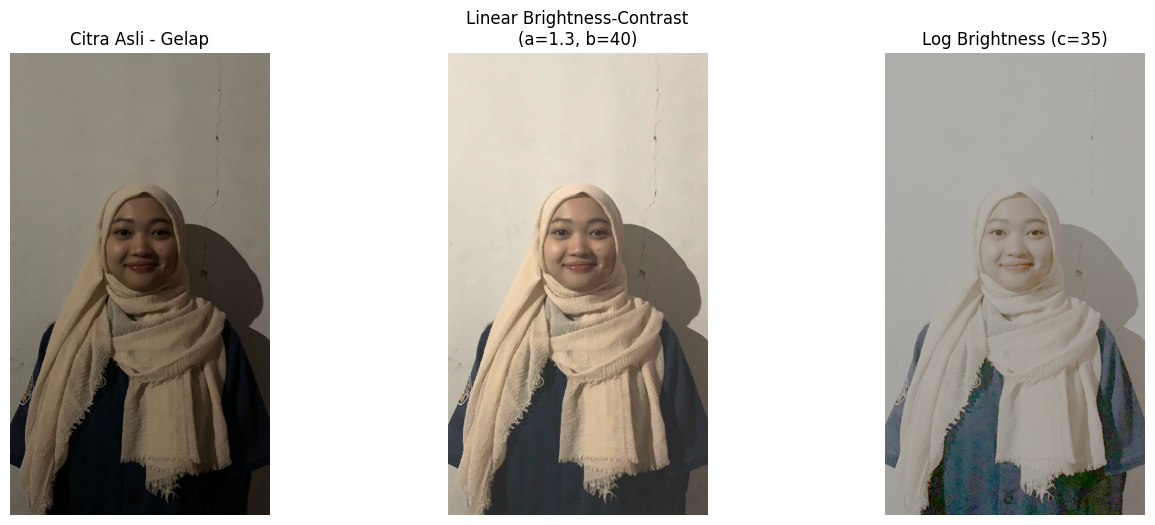

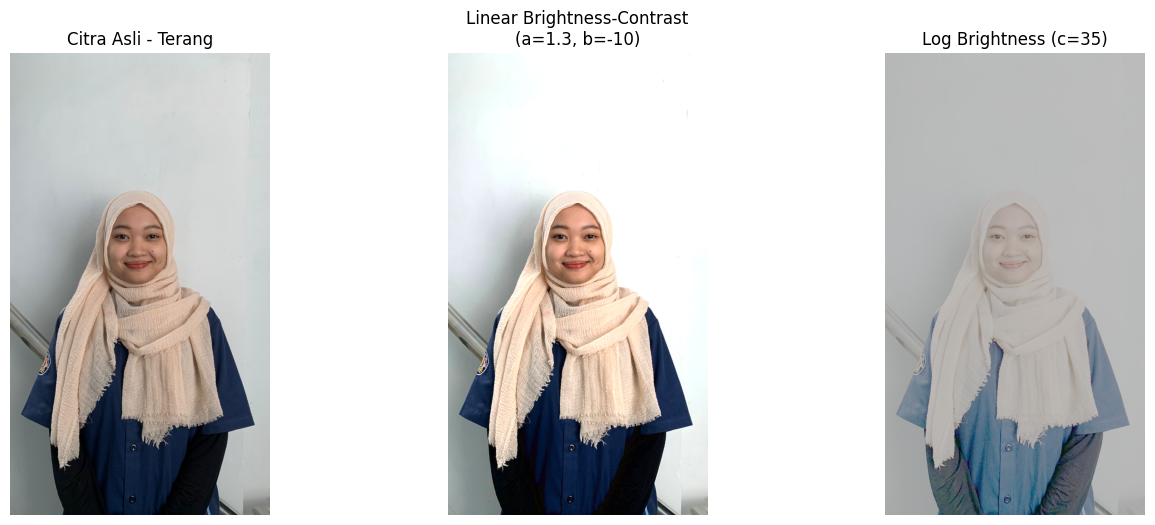

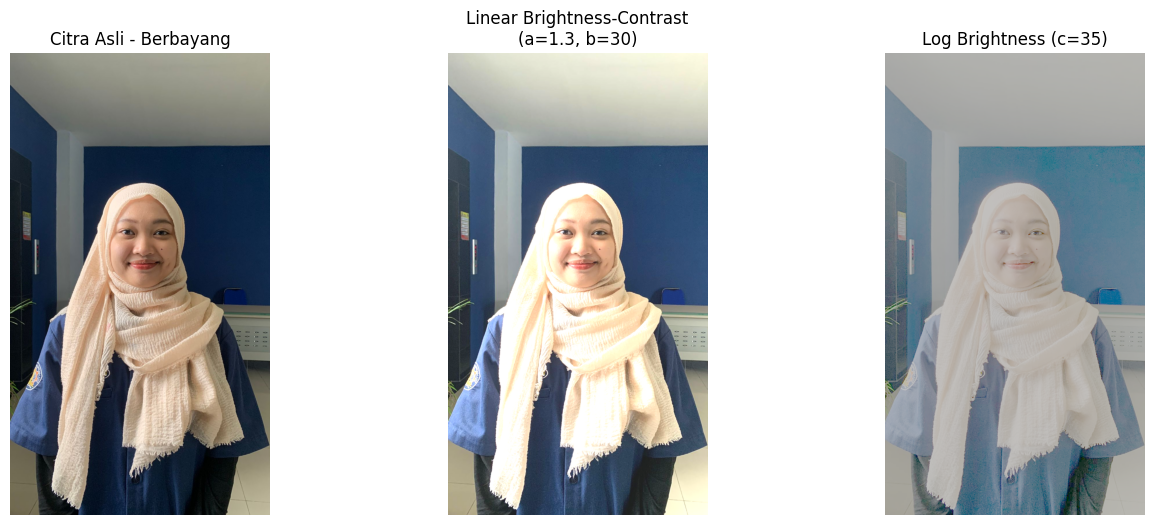

In [ ]:
def apply_brightness_contrast(img, brightness=30, contrast=1.5):
    return cv.convertScaleAbs(img, alpha=a, beta=b)

# Log Brightness
def log_brightness(img, c=40):
    img_float = img.astype(np.float32)
    log_img = c * np.log(1 + img_float)
    log_img = np.uint8(np.clip(log_img, 0, 255))
    return log_img

# transformasi & tampilkan hasil
for name, img in images.items():
    # Linear transform
    if name == 'Gelap':
        a, b = 1.3, 40   # kontras tinggi, brightness besar
    elif name == 'Berbayang':
        a, b = 1.3, 30  # sedikit lebih cerah, tetap natural
    else:  # Terang
        a, b = 1.3, -10  # kurangi sedikit cahaya

    img_linear = cv.convertScaleAbs(img, alpha=a, beta=b)
    img_log = log_brightness(img, c=35)

    # Tampilkan hasil visual
    plt.figure(figsize=(16,6))
    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title(f'Citra Asli - {name}')
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(img_linear)
    plt.title(f'Linear Brightness-Contrast\n(a={a}, b={b})')
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(img_log)
    plt.title(f'Log Brightness (c=35)')
    plt.axis('off')

    plt.show()

3. Lakukan histogram equalization untuk memperbaiki sebaran kontras.
    - Bandingkan hasil visual dan histogram sebelum–sesudah.

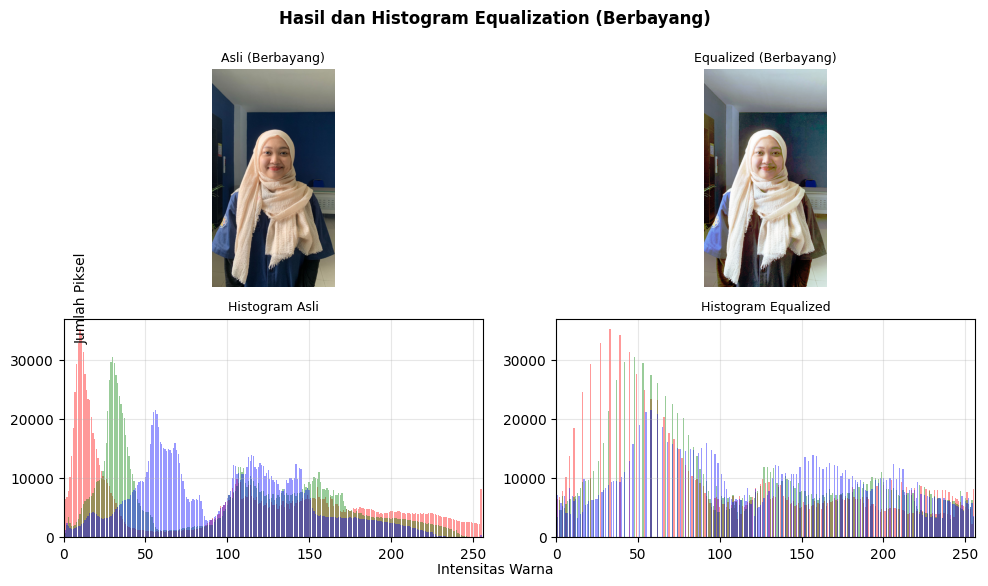

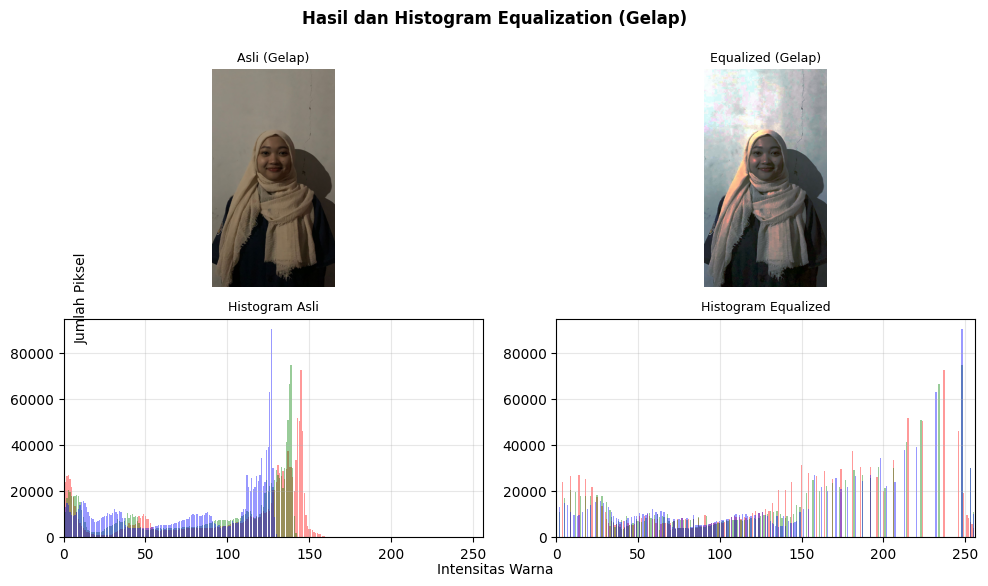

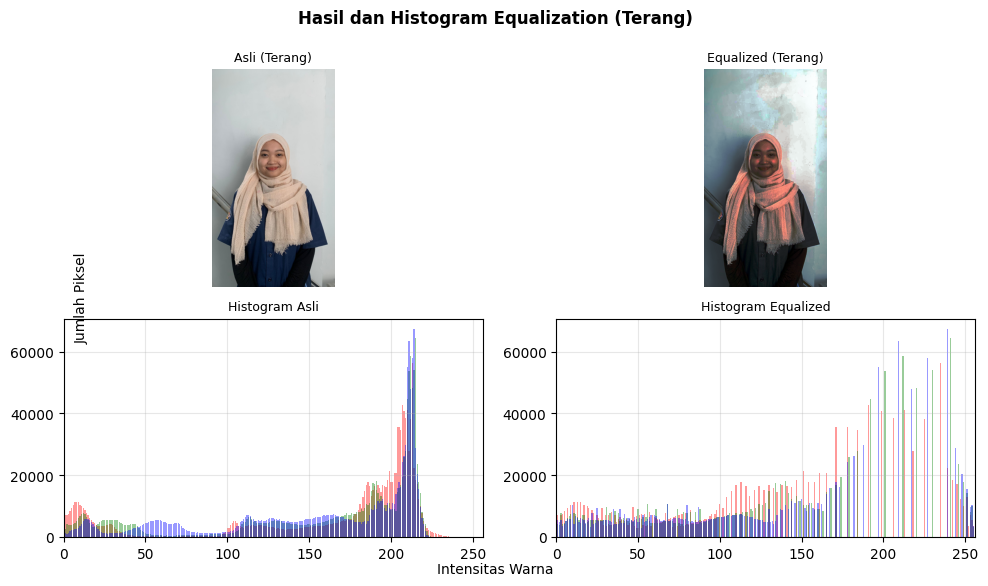

In [ ]:
def equalize_rgb(img):
    r, g, b = cv.split(img)
    r_eq = cv.equalizeHist(r)
    g_eq = cv.equalizeHist(g)
    b_eq = cv.equalizeHist(b)
    return cv.merge((r_eq, g_eq, b_eq))

# Equalization untuk 3 citra
eq_berbayang = equalize_rgb(img_berbayang)
eq_gelap     = equalize_rgb(img_gelap)
eq_terang    = equalize_rgb(img_terang)

# --- Visualisasi sebelum & sesudah ---
images = [
    ("Berbayang", img_berbayang, eq_berbayang),
    ("Gelap", img_gelap, eq_gelap),
    ("Terang", img_terang, eq_terang)
]

colors = ('r', 'g', 'b')
names = np.arange(256)

# === Tampilan: Citra -> Histogram ===
for name, orig, eq in images:
    fig = plt.figure(figsize=(10, 6))  # 🔹 lebih kecil
    fig.suptitle(f"Hasil dan Histogram Equalization ({name})", fontsize=12, weight='bold')

    # --- Bagian 1: Citra Asli & Equalized ---
    ax1 = plt.subplot(2, 2, 1)
    ax1.imshow(orig)
    ax1.set_title(f"Asli ({name})", fontsize=9)
    ax1.axis("off")

    ax2 = plt.subplot(2, 2, 2)
    ax2.imshow(eq)
    ax2.set_title(f"Equalized ({name})", fontsize=9)
    ax2.axis("off")

    # --- Bagian 2: Histogram Asli & Equalized ---
    ax3 = plt.subplot(2, 2, 3)
    for i, col in enumerate(colors):
        hist_orig = cv.calcHist([orig], [i], None, [256], [0, 256]).flatten()
        ax3.bar(names, hist_orig, color=col, alpha=0.4)
    ax3.set_title("Histogram Asli", fontsize=9)
    ax3.set_xlim([0, 256])
    ax3.grid(alpha=0.3)

    ax4 = plt.subplot(2, 2, 4)
    for i, col in enumerate(colors):
        hist_eq = cv.calcHist([eq], [i], None, [256], [0, 256]).flatten()
        ax4.bar(names, hist_eq, color=col, alpha=0.4)
    ax4.set_title("Histogram Equalized", fontsize=9)
    ax4.set_xlim([0, 256])
    ax4.grid(alpha=0.3)

    # Label global
    fig.text(0.5, 0.04, 'Intensitas Warna', ha='center', fontsize=10)
    fig.text(0.08, 0.5, 'Jumlah Piksel', va='center', rotation='vertical', fontsize=10)

    plt.tight_layout()
    plt.subplots_adjust(top=0.88, bottom=0.1)
    plt.show()

4. Terapkan filter spasial:

* Low-pass filter untuk menghaluskan noise kulit wajah.
* High-pass atau Laplacian filter untuk menajamkan tepi mata dan bibir.

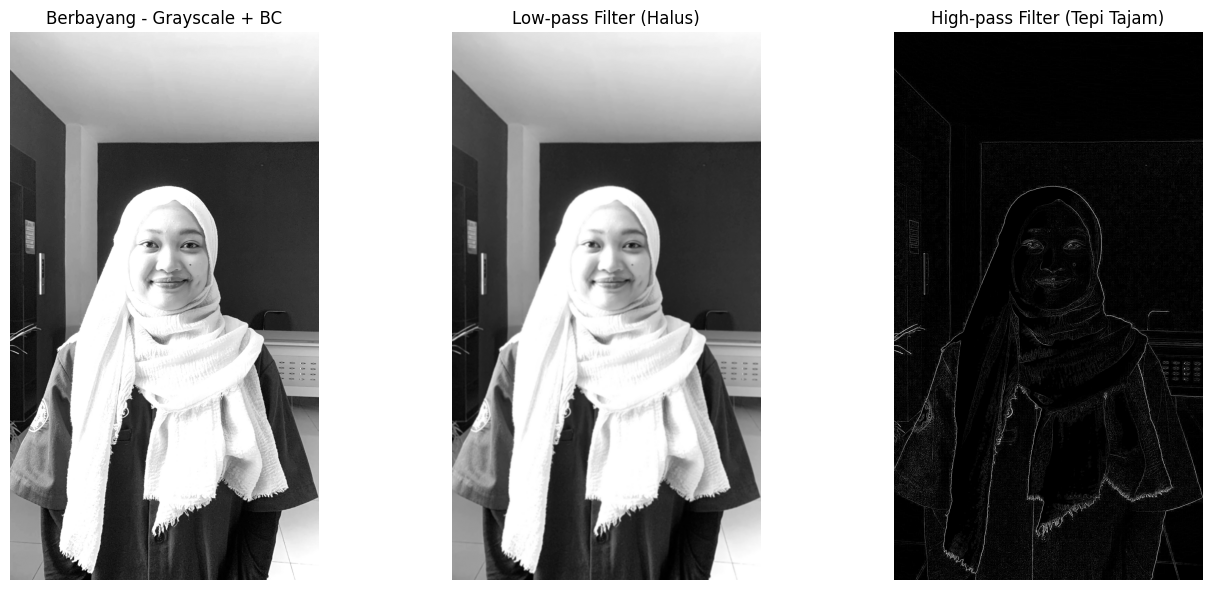

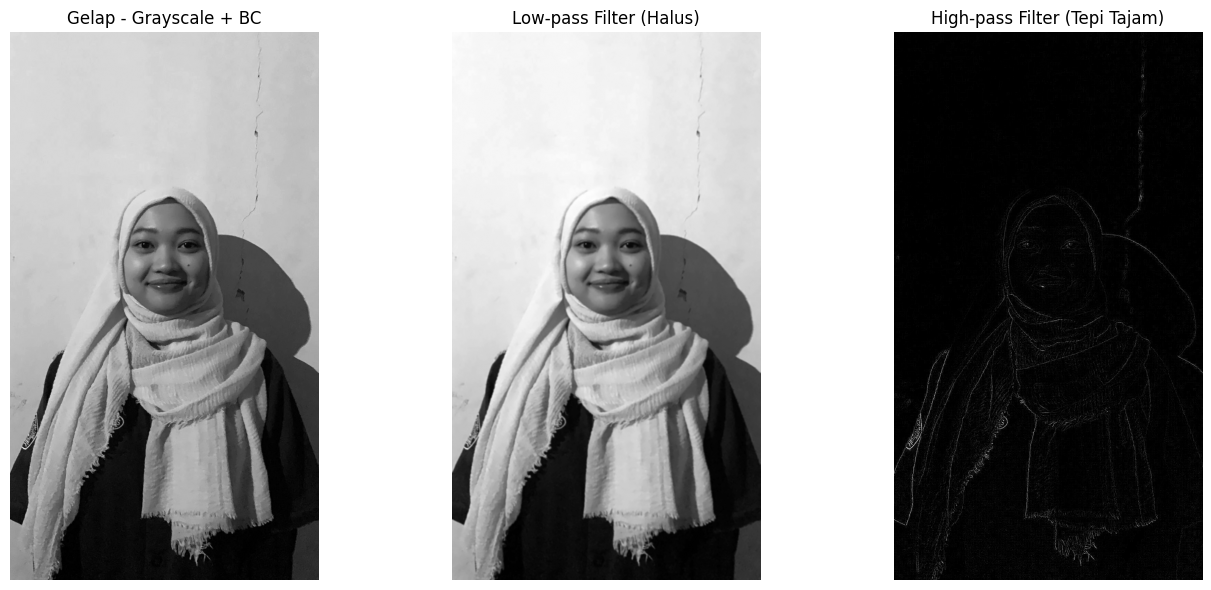

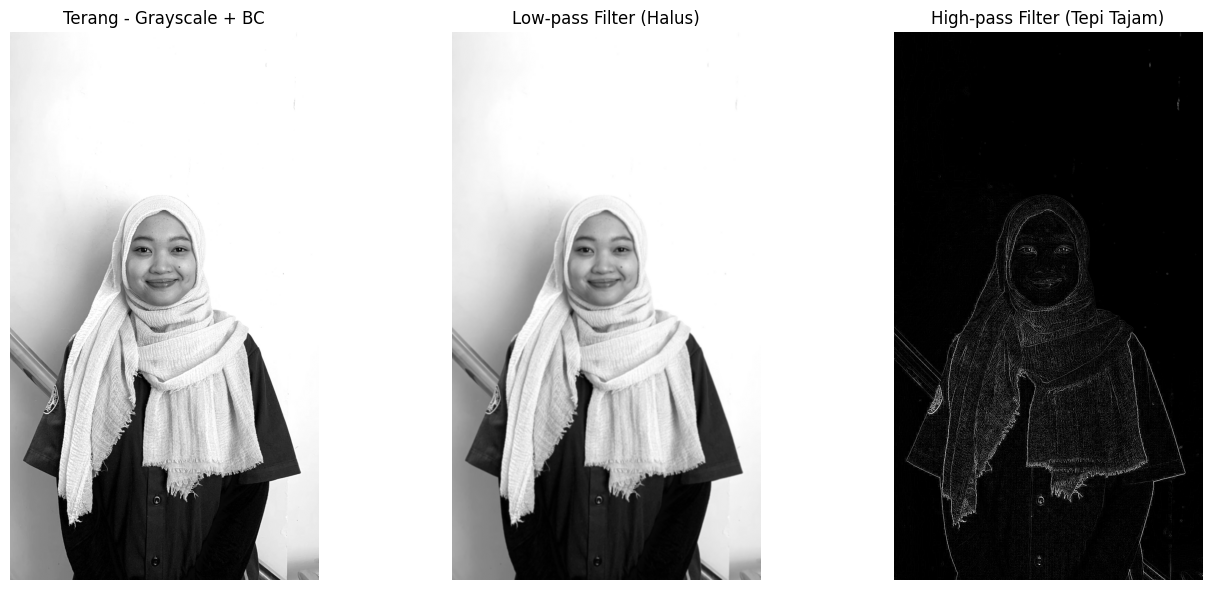

In [ ]:
def apply_brightness_contrast(img, brightness=30, contrast=1.8):
    return cv.convertScaleAbs(img, alpha=contrast, beta=brightness)

images = {
    "Berbayang": img_berbayang,
    "Gelap": img_gelap,
    "Terang": img_terang
}

# === Terapkan Filter Spasial ===
for name, image in images.items():
    # grayscale
    gray = cv.cvtColor(image, cv.COLOR_RGB2GRAY)

    # Atur Brightness & Contrast sesuai kondisi
    if name == 'Gelap':
        img_bc = apply_brightness_contrast(gray, brightness=40, contrast=1.3)
    elif name == 'Berbayang':
        img_bc = apply_brightness_contrast(gray, brightness=30, contrast=1.3)
    else:  # Terang
        img_bc = apply_brightness_contrast(gray, brightness=-10, contrast=1.3)

    # Low-pass filter (menghaluskan noise)
    low_pass = cv.GaussianBlur(img_bc, (7,7), 0)

    # High-pass filter (menajamkan tepi)
    kernel_hp = np.array([
        [-1, -1, -1],
        [-1,  8, -1],
        [-1, -1, -1]
    ])
    high_pass = cv.filter2D(img_bc, -1, kernel_hp)

    # Tampilkan hasil
    plt.figure(figsize=(14,6))

    plt.subplot(1,3,1)
    plt.imshow(img_bc, cmap='gray')
    plt.title(f'{name} - Grayscale + BC')
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(low_pass, cmap='gray')
    plt.title('Low-pass Filter (Halus)')
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(high_pass, cmap='gray')
    plt.title('High-pass Filter (Tepi Tajam)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

5. Implementasikan Floyd–Steinberg Dithering untuk menurunkan kedalaman warna
wajah (bit-depth 4–6 bit), lalu analisis bagaimana efeknya terhadap detail dan ekspresi
wajah.

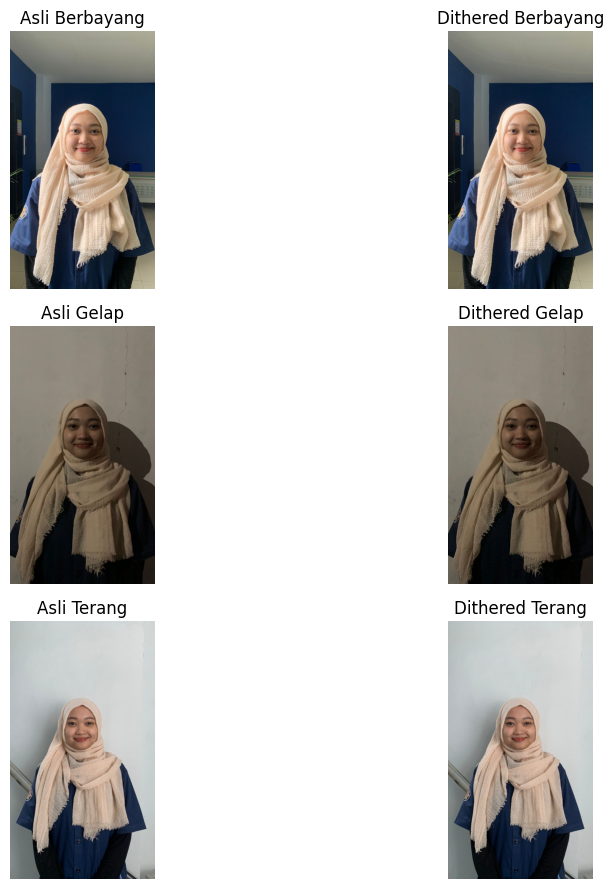

In [ ]:
def floyd_steinberg_dither(img, bit=1):
    """
    Floyd–Steinberg dithering untuk citra RGB
    img : citra RGB (uint8)
    bit : target bit depth (4–6)
    """
    h, w, c = img.shape
    out = img.astype(np.float32).copy()
    levels = 2 ** bit
    step = 256 // levels

    for y in range(h):
        for x in range(w):
            old_pixel = out[y, x].copy()
            new_pixel = np.round(old_pixel / step) * step
            out[y, x] = new_pixel
            quant_error = old_pixel - new_pixel

            if x+1 < w:
                out[y, x+1] += quant_error * 7/16
            if y+1 < h and x > 0:
                out[y+1, x-1] += quant_error * 3/16
            if y+1 < h:
                out[y+1, x] += quant_error * 5/16
            if y+1 < h and x+1 < w:
                out[y+1, x+1] += quant_error * 1/16

    return np.clip(out, 0, 255).astype(np.uint8)

# Terapkan dithering ke citra asli
dither_berbayang_asli = floyd_steinberg_dither(img_berbayang, bit=1)
dither_gelap_asli     = floyd_steinberg_dither(img_gelap, bit=1)
dither_terang_asli    = floyd_steinberg_dither(img_terang, bit=1)

# Visualisasi: Asli vs Dithered
plt.figure(figsize=(12,9))

for i,(name,orig,dither) in enumerate([
    ("Berbayang", img_berbayang, dither_berbayang_asli),
    ("Gelap", img_gelap, dither_gelap_asli),
    ("Terang", img_terang, dither_terang_asli)]):

    plt.subplot(3,2,2*i+1)
    plt.imshow(orig)
    plt.title(f"Asli {name}")
    plt.axis("off")

    plt.subplot(3,2,2*i+2)
    plt.imshow(dither)
    plt.title(f"Dithered {name}")
    plt.axis("off")

plt.tight_layout()
plt.show()



Resolusi terlalu besar, pola titik hasil dithering jadi lebih kecil relatif terhadap ukuran citra, sehingga mata sulit membedakan hasil dithered dengan citra asli. Namun fungsi dari dithering adalah menurunkan bit depth citra, kemudian menyebarkan error kuantisasi ke piksel tetangga (contohnya metode Floyd–Steinberg). Tujuannya adalah agar citra dengan jumlah level warna yang lebih sedikit tetap tampak halus bagi mata manusia.

## B - Analisis

1. Bagaimana perubahan nilai brightness dan contrast mempengaruhi hasil histogram wajah gelap?

Jawab :
Pada citra wajah gelap, area wajah dominan gelap. Setelah diterapkan linear brightness–contrast (a=1.3, b=40), wajah menjadi lebih cerah dan detail mulai muncul (mata, hidung, dan bibir terlihat jelas). Hal ini menunjukkan bahwa sebaran intensitas piksel yang sebelumnya terkonsentrasi di area gelap kini lebih merata.
Dengan log brightness (c=35), wajah tampak jauh lebih terang, tetapi beberapa bagian menjadi terlalu pucat (overexposed). Hal ini menandakan distribusi intensitas terlalu terdorong ke arah terang.
Secara visual, kombinasi peningkatan brightness dan kontras secara linear menghasilkan wajah yang lebih natural dibandingkan metode log, karena tidak menghilangkan detail pada bagian terang.


2. Apakah histogram equalization selalu memperbaiki detail wajah? Jelaskan alasannya dengan contoh hasil Anda.

Jawab :
-  Citra Gelap
    - Sebelum equalization: Histogram sangat sempit, menandakan citra underexposed.
    - Sesudah equalization: Histogram melebar tajam, tetapi banyak puncak tinggi di sisi kanan (intensitas >200).

- Citra Terang
  - Sebelum equalization: Histogram sudah merata di intensitas menengah–tinggi (100–220). Wajah sudah tampak natural.
  - Sesudah equalization: Histogram berubah ekstrim: sebagian besar nilai bergeser ke sisi kanan. Citra menjadi terlalu kontras dan sedikit kemerahan, terutama pada channel R.

- Citra Berbayang
  - Sebelum equalization: Histogram R, G, dan B menumpuk di area kiri (intensitas rendah). Wajah terlihat agak gelap di bagian kanan dan tidak merata pencahayaannya.
  - Sesudah equalization: Histogram menjadi lebih menyebar di seluruh rentang 0–255, terutama pada channel R dan G. Wajah tampak lebih cerah dan detail kulit lebih muncul, terutama di area yang sebelumnya gelap.


3. Bandingkan hasil low-pass dan high-pass filter pada area wajah — bagian mana yang paling terpengaruh?
Jawab :
- Low-pass filter (Gaussian Blur / halus)
  - Efeknya paling terlihat pada tekstur kulit wajah: noda kecil, kerutan, atau noise di pipi menjadi lebih lembut. Area detail kain (pashmina, baju) juga menjadi lebih rata dan kehilangan detail tajam. Secara umum, low-pass membuat wajah tampak lebih halus, tetapi detail tepi (mata, mulut, kontur hidung) ikut sedikit berkurang.
- High-pass filter (deteksi tepi / tajam)
  - Efek paling kuat muncul pada batas tepi wajah, garis rambut, serta fitur tegas seperti mata, bibir, dan hidung. Tekstur kain kerudung dan pakaian muncul sangat jelas karena kontras tepi diperkuat.Namun, informasi tonal (area kulit yang halus) justru hilang karena hanya kontur yang disorot


4. Mengapa proses dithering bisa mempertegas atau justru mengaburkan ekspresi wajah?

Jawab :
Dithering adalah teknik kuantisasi warna atau intensitas dengan cara menurunkan bit depth citra, kemudian menyebarkan error kuantisasi ke piksel tetangga.  Tujuannya adalah agar citra dengan jumlah level warna yang lebih sedikit tetap tampak halus bagi mata manusia.  
- Pada area dengan kontras tinggi (misalnya tepi mata, bibir, hidung), error kuantisasi yang disebarkan menghasilkan pola bintik yang justru menonjolkan batas antar-piksel. Akibatnya, fitur ekspresi wajah terlihat lebih jelas karena ada “tekanan kontras” tambahan dari pola dithering.
- Pada area dengan gradasi halus (seperti kulit pipi, dahi), dithering menghilangkan transisi lembut dan menggantinya dengan pola titik. Hal ini membuat wajah tampak kasar atau bercak-bercak, sehingga ekspresi halus (misalnya senyum tipis) bisa hilang atau tampak kurang natural.

Namun, pada hasil implementasi resolusi terlalu besar. Pola titik hasil dithering jadi lebih kecil relatif terhadap ukuran citra, sehingga mata sulit membedakan hasil dithered dengan citra asli.


5. Berdasarkan hasil percobaan Anda, kombinasi teknik mana yang paling efektif untuk meningkatkan readability fitur wajah sebelum tahap deteksi?

Jawab :  
- Brightness–Contrast menormalkan pencahayaan, sehingga wajah yang gelap menjadi lebih terang dan wajah yang terlalu terang bisa dikoreksi.
- Histogram Equalization meratakan distribusi intensitas, membuat detail di area gelap maupun terang lebih terlihat.
- Low-pass Filtering (Gaussian Blur) mengurangi noise dan membuat kulit wajah lebih halus.
- High-pass Filtering (Laplacian/Sharpening) mempertegas fitur penting seperti mata, hidung, dan bibir


## D – Analisis Akhir & Kesimpulan

1.  Urutan proses terbaik untuk menghasilkan wajah paling siap recognition

- Brightness–Contrast: menormalkan pencahayaan agar wajah tidak terlalu gelap atau terlalu terang.
- Histogram Equalization: memperbaiki distribusi intensitas sehingga detail wajah lebih merata.
- Low-pass Filtering: mengurangi noise dan membuat kulit wajah lebih halus.
- High-pass Filtering: menegaskan fitur penting (mata, hidung, bibir) untuk membantu sistem pengenalan wajah.

2.  Perbandingan nilai PSNR antara citra asli yang memiliki pencahanyaan baik dan hasil pra-pemrosesan


=== Nilai PSNR terhadap citra asli terang ===
Gaussian Blur (3x3): 40.37 dB
Gaussian Blur (5x5): 38.56 dB
Sharpen Filter (3x3): 34.28 dB
Sharpen Filter (5x5): 35.71 dB


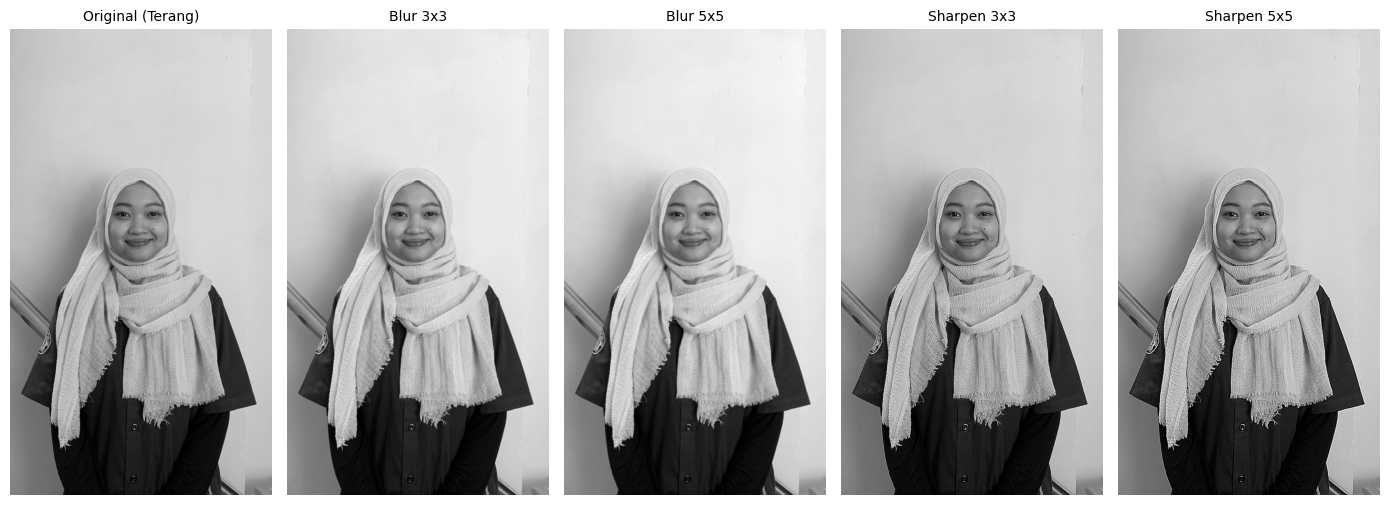

In [ ]:
# Fungsi PSNR
def calculate_psnr(original, processed):
    mse = np.mean((original - processed) ** 2)
    if mse == 0:
        return float('inf')  # jika identik
    psnr = 10 * np.log10((255 ** 2) / mse)
    return psnr

# Ambil citra asli
original = cv.cvtColor(img_terang, cv.COLOR_RGB2GRAY)

#  Terapkan berbagai filter untuk perbandingan
# Gaussian Blur 3x3 dan 5x5
blur3 = cv.GaussianBlur(original, (3, 3), 0)
blur5 = cv.GaussianBlur(original, (5, 5), 0)

# Sharpening kernel 3x3 dan 5x5
kernel_sharp3 = np.array([[0, -1, 0],
                          [-1, 5, -1],
                          [0, -1, 0]])

kernel_sharp5 = np.array([[-1, -1, -1, -1, -1],
                          [-1,  2,  2,  2, -1],
                          [-1,  2,  8,  2, -1],
                          [-1,  2,  2,  2, -1],
                          [-1, -1, -1, -1, -1]]) / 8.0

sharp3 = cv.filter2D(original, -1, kernel_sharp3)
sharp5 = cv.filter2D(original, -1, kernel_sharp5)

# Hitung PSNR untuk masing-masing hasil
psnr_blur3 = calculate_psnr(original, blur3)
psnr_blur5 = calculate_psnr(original, blur5)
psnr_sharp3 = calculate_psnr(original, sharp3)
psnr_sharp5 = calculate_psnr(original, sharp5)

# Tampilkan hasil PSNR
print("=== Nilai PSNR terhadap citra asli terang ===")
print(f"Gaussian Blur (3x3): {psnr_blur3:.2f} dB")
print(f"Gaussian Blur (5x5): {psnr_blur5:.2f} dB")
print(f"Sharpen Filter (3x3): {psnr_sharp3:.2f} dB")
print(f"Sharpen Filter (5x5): {psnr_sharp5:.2f} dB")

# Visualisasi hasil citra
titles = ['Original (Terang)', 'Blur 3x3', 'Blur 5x5', 'Sharpen 3x3', 'Sharpen 5x5']
images = [original, blur3, blur5, sharp3, sharp5]

plt.figure(figsize=(14,6))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i], fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

* Gaussian Blur 3×3 (40,37 dB) → Memiliki nilai PSNR tertinggi, hasil paling mendekati citra asli dengan sedikit perubahan.

* Gaussian Blur 5×5 (38,56 dB) → Sedikit menurunkan PSNR karena efek perataan lebih kuat, namun tetap mempertahankan detail wajah.

* Sharpen Filter 3×3 (34,28 dB) → PSNR menurun karena peningkatan tepi membuat perbedaan piksel lebih besar, tetapi fitur wajah menjadi lebih tajam.

* Sharpen Filter 5×5 (35,71 dB) → Penajaman lebih kuat, PSNR tetap rendah namun menghasilkan fitur wajah yang lebih jelas.

3. Rekomendasi metode peningkatan kualitas wajah untuk sistem pengenalan wajah real-time



*   Penyesuaian brightness dan contrast (Linear Transformation), karena teknik ini efektif menormalkan pencahayaan agar fitur wajah seperti mata, hidung, dan bibir terlihat lebih jelas, bahkan dalam kondisi cahaya yang tidak stabil. Prosesnya ringan secara komputasi karena hanya menggunakan operasi sederhana pada piksel, sehingga cocok untuk sistem real-time. Dengan penyesuaian ini, citra wajah menjadi lebih seimbang dan mudah dikenali oleh algoritma pengenalan wajah
